## Vijay Hanumandla
## Roll No: 23102C0071
## Experiment No 04
## AML
## CMPN - C
Objective : Perform multiclass classification using the One-vs-Rest (OvR) strategy and evaluate the model using the Weighted F1-score.

> Add blockquote



## Step 1 : Import Required Libraries

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step : Load the Dataset

In [2]:
# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)

Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']


## Step 3 : Display the Dataset

In [3]:
# Convert dataset into a DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Step 4 : Check Dataset Information

In [4]:
# Display basic information about the dataset

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["species"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


## Step 5 : Split Dataset into Training and Testing Data

In [5]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Step 6 : Feature Scaling

In [6]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## Step 7 : Create One-vs-Rest Model

In [7]:
# Create Logistic Regression classifier

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Apply One-vs-Rest strategy

ovr_model = OneVsRestClassifier(logistic_model)

print("One-vs-Rest model created successfully!")

One-vs-Rest model created successfully!


## Step 8 : Train the Model

In [8]:
# Train the One-vs-Rest model

ovr_model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Step 9 : Make Predictions

In [9]:
# Make predictions on test data

y_pred = ovr_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("\nPredicted classes:")
print(y_pred)

print("\nActual classes:")
print(y_test)

Predictions generated successfully!

Predicted classes:
[0 2 1 1 0 2 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Actual classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## Step 10 : Calculate Accuracy

In [10]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9
Accuracy (%): 90.0


## Step 11 : Calculate Precision

In [11]:
# Calculate weighted precision

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Weighted Precision:", weighted_precision)

Weighted Precision: 0.9023569023569025


## Step 12 : Calculate Recall

In [12]:
# Calculate weighted recall

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Weighted Recall:", weighted_recall)

Weighted Recall: 0.9


## Step 13 : Calculate Weighted F1-Score

In [13]:
# Calculate weighted F1-score

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Weighted F1-Score:", weighted_f1)

Weighted F1-Score: 0.8997493734335839


## Step 14 : Display Complete Classification Report

In [14]:
# Display classification report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## Step 15 : Confusion Matrix

In [15]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


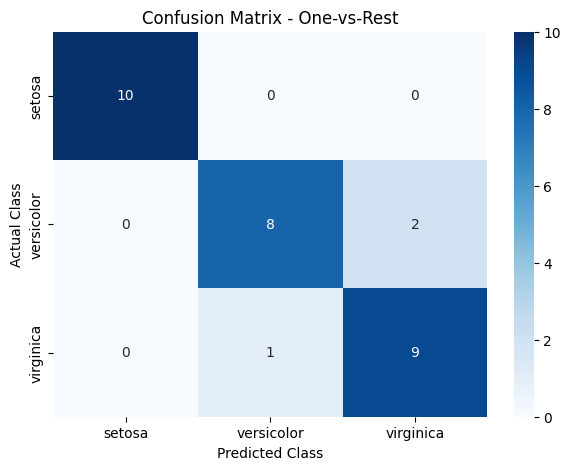

In [16]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - One-vs-Rest")
plt.show()

## Step 16 : Compare All Metrics

In [17]:
# Compare evaluation metrics

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Weighted Precision": precision_score(y_test, y_pred, average="weighted"),
    "Weighted Recall": recall_score(y_test, y_pred, average="weighted"),
    "Weighted F1-Score": f1_score(y_test, y_pred, average="weighted")
}

results = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

results

,Metric,Score
0,Accuracy,0.900000
1,Weighted Precision,0.902357
2,Weighted Recall,0.900000
3,Weighted F1-Score,0.899749


## Step 17 : Plot the Evaluation Metrics

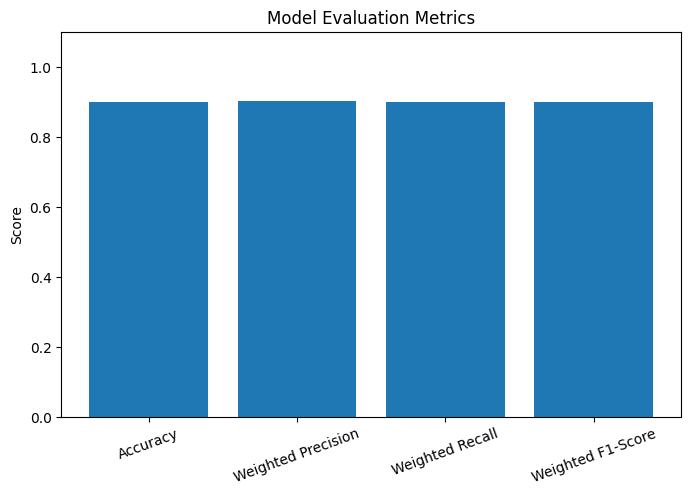

In [18]:
# Plot evaluation metrics

plt.figure(figsize=(8, 5))

plt.bar(
    results["Metric"],
    results["Score"]
)

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics")
plt.xticks(rotation=20)
plt.show()

## Step 18 : Verify One-vs-Rest Classifiers

In [19]:
# Display the number of One-vs-Rest classifiers

print("Number of classes:", len(iris.target_names))
print("Number of One-vs-Rest classifiers:", len(ovr_model.estimators_))

for i, class_name in enumerate(iris.target_names):
    print(f"Classifier {i + 1}: {class_name} vs Rest")

Number of classes: 3
Number of One-vs-Rest classifiers: 3
Classifier 1: setosa vs Rest
Classifier 2: versicolor vs Rest
Classifier 3: virginica vs Rest


## Step 19 : Final Combined Code

In [20]:
# ==========================================
# FINAL RESULTS
# Experiment 4 - Advanced Metrics
# ==========================================

print("=" * 50)
print("EXPERIMENT 4 - ADVANCED METRICS")
print("=" * 50)

print("\nDataset: Iris Dataset")
print("Algorithm: Logistic Regression")
print("Classification Strategy: One-vs-Rest")

print("\nNumber of Classes:", len(iris.target_names))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\n--- Evaluation Results ---")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Weighted Precision:",
      precision_score(y_test, y_pred, average="weighted"))

print("Weighted Recall:",
      recall_score(y_test, y_pred, average="weighted"))

print("Weighted F1-Score:",
      f1_score(y_test, y_pred, average="weighted"))

print("\n--- One-vs-Rest Classifiers ---")

for i, class_name in enumerate(iris.target_names):
    print(f"Classifier {i + 1}: {class_name} vs Rest")

print("\nExperiment completed successfully!")

EXPERIMENT 4 - ADVANCED METRICS

Dataset: Iris Dataset
Algorithm: Logistic Regression
Classification Strategy: One-vs-Rest

Number of Classes: 3
Training Samples: 120
Testing Samples: 30

--- Evaluation Results ---
Accuracy: 0.9
Weighted Precision: 0.9023569023569025
Weighted Recall: 0.9
Weighted F1-Score: 0.8997493734335839

--- One-vs-Rest Classifiers ---
Classifier 1: setosa vs Rest
Classifier 2: versicolor vs Rest
Classifier 3: virginica vs Rest

Experiment completed successfully!


## Step 20 : Conclusion


The multiclass classification problem was successfully implemented using the One-vs-Rest strategy with Logistic Regression on the Iris dataset. The dataset was divided into training and testing sets and the features were standardized before training the model.

The One-vs-Rest approach created a separate binary classifier for each of the three Iris classes: Setosa, Versicolor, and Virginica. The model was evaluated using accuracy, weighted precision, weighted recall, and weighted F1-score.

The weighted F1-score provided a balanced measure of the model's precision and recall across all classes. The obtained evaluation results show that the One-vs-Rest Logistic Regression model performs effectively for multiclass classification on the Iris dataset.

Therefore, the objective of performing multiclass classification using One-vs-Rest and evaluating the model using weighted F1-score was successfully achieved.
